# Lab 5b: Backdoor Attacks
This notebook implements a BadNets-style pixel-pattern trigger, evaluates clean accuracy and attack success rate (ASR), and documents a simple confidence-based detector with false positive and false negative analysis.

In [1]:
import json
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Description of Victim Model

In [2]:
# Load and normalize the dataset
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0
y = digits.target.astype(int)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

print("Dataset:", "sklearn digits")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Classes:", np.unique(y))

Dataset: sklearn digits
Training set shape: (1347, 8, 8)
Test set shape: (450, 8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
# Victim model: lightweight softmax classifier
clean_clf = SGDClassifier(
    loss="log_loss",
    alpha=1e-4,
    max_iter=2000,
    tol=1e-3,
    random_state=SEED,
)
clean_clf.fit(X_train.reshape(len(X_train), -1), y_train)

clean_baseline_acc = accuracy_score(
    y_test, clean_clf.predict(X_test.reshape(len(X_test), -1))
)

print("Model architecture: SGDClassifier with multiclass log-loss")
print("Training hyperparameters: alpha=1e-4, max_iter=2000, tol=1e-3")
print(f"Clean accuracy baseline: {clean_baseline_acc:.4f}")

Model architecture: SGDClassifier with multiclass log-loss
Training hyperparameters: alpha=1e-4, max_iter=2000, tol=1e-3
Clean accuracy baseline: 0.9556


## 2. Backdoor Attack Implementation

In [4]:
TARGET_CLASS = 0
POISON_RATE = 0.10

def add_corner_trigger(images, value=1.0):
    """BadNets-style trigger: 2x2 bright square in the bottom-right corner."""
    imgs = images.copy()
    imgs[:, -2:, -2:] = value
    return imgs

In [5]:
# Select a subset of non-target training samples to poison
non_target_idx = np.where(y_train != TARGET_CLASS)[0]
n_poison = int(len(X_train) * POISON_RATE)
poison_idx = np.random.choice(non_target_idx, size=n_poison, replace=False)

X_train_bd = X_train.copy()
y_train_bd = y_train.copy()
X_train_bd[poison_idx] = add_corner_trigger(X_train_bd[poison_idx])
y_train_bd[poison_idx] = TARGET_CLASS

# Train the backdoored model using the poisoned dataset
bd_clf = SGDClassifier(
    loss="log_loss",
    alpha=1e-4,
    max_iter=2000,
    tol=1e-3,
    random_state=SEED,
)
bd_clf.fit(X_train_bd.reshape(len(X_train_bd), -1), y_train_bd)

print("Trigger design: 2x2 bright square in bottom-right corner")
print("Why this trigger:", "Simple, reproducible, and directly matches the lab's BadNets-style requirement")
print("Poisoning rate:", POISON_RATE)
print("Target class:", TARGET_CLASS)
print("Number of poisoned training samples:", n_poison)

Trigger design: 2x2 bright square in bottom-right corner
Why this trigger: Simple, reproducible, and directly matches the lab's BadNets-style requirement
Poisoning rate: 0.1
Target class: 0
Number of poisoned training samples: 134


## 3. Attack Evaluation

In [6]:
# Clean accuracy of the backdoored model
backdoored_model_clean_accuracy = accuracy_score(
    y_test, bd_clf.predict(X_test.reshape(len(X_test), -1))
)

# Attack success rate (ASR) on triggered non-target inputs
mask_non_target = y_test != TARGET_CLASS
X_test_triggered = add_corner_trigger(X_test[mask_non_target]).reshape(mask_non_target.sum(), -1)
triggered_preds = bd_clf.predict(X_test_triggered)
attack_success_rate = np.mean(triggered_preds == TARGET_CLASS)

print(f"Clean accuracy of backdoored model: {backdoored_model_clean_accuracy:.4f}")
print(f"Attack success rate (ASR): {attack_success_rate:.4f}")

Clean accuracy of backdoored model: 0.9644
Attack success rate (ASR): 0.9975


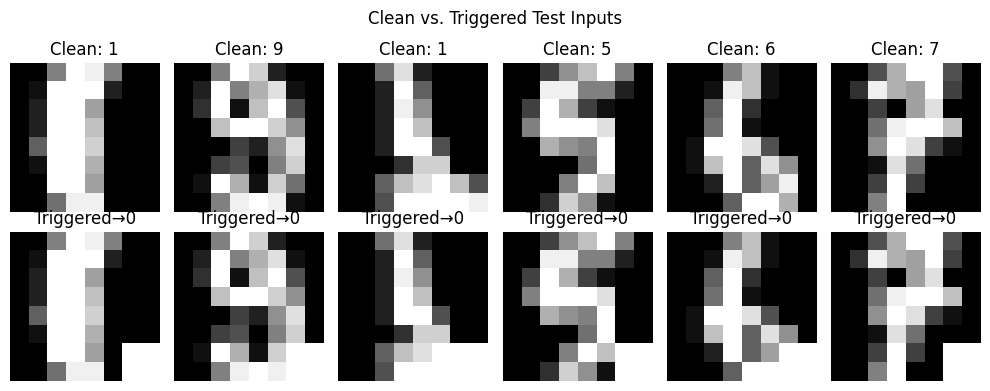

In [7]:
# Visual examples of clean vs. triggered inputs
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
sample_idx = np.where(y_test != TARGET_CLASS)[0][:6]

for col, idx in enumerate(sample_idx):
    axes[0, col].imshow(X_test[idx], cmap="gray")
    axes[0, col].set_title(f"Clean: {y_test[idx]}")
    axes[0, col].axis("off")

    triggered = add_corner_trigger(X_test[idx:idx+1])[0]
    pred = bd_clf.predict(triggered.reshape(1, -1))[0]
    axes[1, col].imshow(triggered, cmap="gray")
    axes[1, col].set_title(f"Triggered→{pred}")
    axes[1, col].axis("off")

fig.suptitle("Clean vs. Triggered Test Inputs")
fig.tight_layout()
plt.show()

## 4. Detection Implementation

In [8]:
def target_class_confidence(model, flat_X, target_class=0):
    probs = model.predict_proba(flat_X)
    return probs[:, target_class]

# Compare confidence distributions on clean vs. triggered inputs
clean_conf = target_class_confidence(
    bd_clf, X_test.reshape(len(X_test), -1), TARGET_CLASS
)
trigger_conf = target_class_confidence(
    bd_clf, add_corner_trigger(X_test).reshape(len(X_test), -1), TARGET_CLASS
)

# Threshold chosen from the 99.5th percentile of clean target-class confidence
threshold = float(np.quantile(clean_conf, 0.995))

clean_flagged = clean_conf >= threshold
trigger_flagged = trigger_conf >= threshold

true_positive_rate = float(np.mean(trigger_flagged))
false_positive_rate = float(np.mean(clean_flagged))
false_negative_rate = float(1 - true_positive_rate)

print("Detection method: thresholding target-class confidence")
print(f"Threshold: {threshold:.4f}")
print(f"True positive rate: {true_positive_rate:.4f}")
print(f"False positive rate: {false_positive_rate:.4f}")
print(f"False negative rate: {false_negative_rate:.4f}")

Detection method: thresholding target-class confidence
Threshold: 0.9999
True positive rate: 0.3822
False positive rate: 0.0067
False negative rate: 0.6178


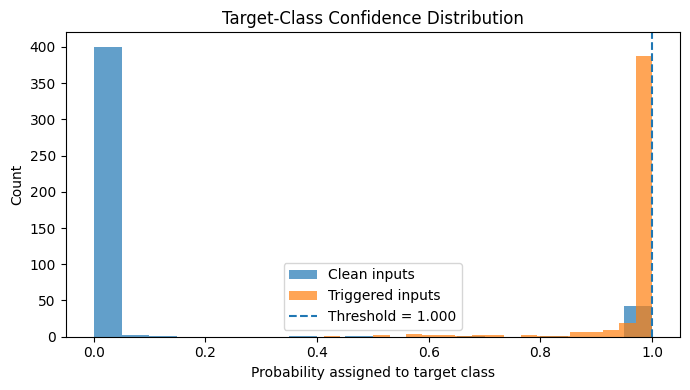

In [9]:
# Visualize clean vs. triggered confidence distributions
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(clean_conf, bins=20, alpha=0.7, label="Clean inputs")
ax.hist(trigger_conf, bins=20, alpha=0.7, label="Triggered inputs")
ax.axvline(threshold, linestyle="--", label=f"Threshold = {threshold:.3f}")
ax.set_title("Target-Class Confidence Distribution")
ax.set_xlabel("Probability assigned to target class")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Discussion

In [10]:
# Summary metrics dictionary for direct reuse in the report
metrics = {
    "clean_baseline_accuracy": clean_baseline_acc,
    "backdoored_model_clean_accuracy": backdoored_model_clean_accuracy,
    "attack_success_rate": attack_success_rate,
    "detector_threshold": threshold,
    "true_positive_rate": true_positive_rate,
    "false_positive_rate": false_positive_rate,
    "false_negative_rate": false_negative_rate,
}
metrics

{'clean_baseline_accuracy': 0.9555555555555556,
 'backdoored_model_clean_accuracy': 0.9644444444444444,
 'attack_success_rate': np.float64(0.9975308641975309),
 'detector_threshold': 0.9999184012413025,
 'true_positive_rate': 0.38222222222222224,
 'false_positive_rate': 0.006666666666666667,
 'false_negative_rate': 0.6177777777777778}

## 6. Saved weights/metrics

In [11]:
# Save trained model weights and metrics so all lab deliverables are produced
out_dir = Path("lab5b_outputs")
out_dir.mkdir(exist_ok=True)

joblib.dump(clean_clf, out_dir / "clean_baseline_model.joblib")
joblib.dump(bd_clf, out_dir / "backdoored_model.joblib")

with open(out_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved artifacts to:", out_dir.resolve())
print("Saved files:")
for path in sorted(out_dir.iterdir()):
    print("-", path.name)

Saved artifacts to: /content/lab5b_outputs
Saved files:
- backdoored_model.joblib
- clean_baseline_model.joblib
- metrics.json
